100%|██████████| 26.4M/26.4M [06:16<00:00, 70.1kB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 157kB/s]
100%|██████████| 4.42M/4.42M [00:55<00:00, 80.3kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.4MB/s]


Epoch 1: Loss=1.0444, Test Acc=0.7243
Epoch 2: Loss=0.5976, Test Acc=0.8104
Epoch 3: Loss=0.5236, Test Acc=0.8109
Epoch 4: Loss=0.4831, Test Acc=0.8269
Epoch 5: Loss=0.4548, Test Acc=0.7970
Epoch 6: Loss=0.4362, Test Acc=0.8269
Epoch 7: Loss=0.4169, Test Acc=0.8363
Epoch 8: Loss=0.4074, Test Acc=0.8359
Epoch 9: Loss=0.3930, Test Acc=0.8481
Epoch 10: Loss=0.3843, Test Acc=0.8355


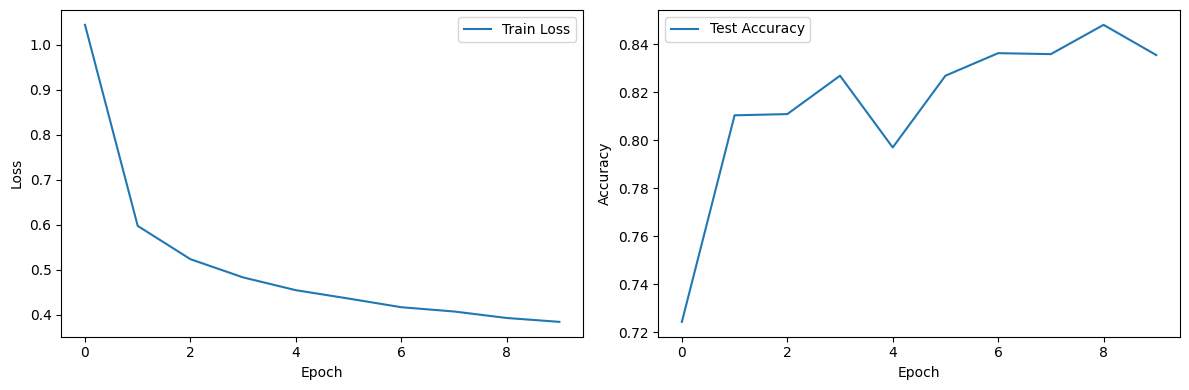

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# 加载Fashion-MNIST数据集
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)) 
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

batch_size = 256
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 参数初始化
input_size = 784   # 28x28
hidden_size = 256
output_size = 10

# 正态分布初始化
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

# 设置requires_grad
W1.requires_grad_(True)
b1.requires_grad_(True)
W2.requires_grad_(True)
b2.requires_grad_(True)

# ReLU激活函数
def relu(x):
    return torch.maximum(torch.tensor(0.0), x)

# Softmax + 交叉熵损失
def softmax_cross_entropy(logits, y):
   
    logits = logits - logits.max(dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits)
    softmax = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    
    
    n = y.shape[0]
    loss = -torch.log(softmax[range(n), y] + 1e-8).mean()
    return loss

# 前向传播
def forward(X):
    h = X @ W1 + b1
    h = relu(h)
    o = h @ W2 + b2
    return o, h

# 训练参数
lr = 0.1
epochs = 10

train_losses = []
test_accs = []

for epoch in range(epochs):
    epoch_loss = 0
    for X, y in train_loader:
        # 前向传播
        logits, _ = forward(X)
        loss = softmax_cross_entropy(logits, y)
        
        # 反向传播（手动计算梯度）
        n = X.shape[0]
        
        # 输出层梯度
        softmax = torch.exp(logits - logits.max(dim=1, keepdim=True)[0])
        softmax = softmax / softmax.sum(dim=1, keepdim=True)
        softmax[range(n), y] -= 1
        grad_logits = softmax / n
        
        h = relu(X @ W1 + b1)
        grad_W2 = h.T @ grad_logits
        grad_b2 = grad_logits.sum(dim=0)
        grad_h = grad_logits @ W2.T
        
        # ReLU反向
        grad_h[h <= 0] = 0
        
        # 隐藏层梯度
        grad_W1 = X.T @ grad_h
        grad_b1 = grad_h.sum(dim=0)
        
        # SGD更新
        with torch.no_grad():
            W2 -= lr * grad_W2
            b2 -= lr * grad_b2
            W1 -= lr * grad_W1
            b1 -= lr * grad_b1
        
        epoch_loss += loss.item()
    
    # 测试准确率
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:
            logits, _ = forward(X)
            pred = torch.argmax(logits, dim=1)
            correct += (pred == y).sum().item()
            total += y.shape[0]
    
    train_losses.append(epoch_loss / len(train_loader))
    test_accs.append(correct / total)
    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Test Acc={test_accs[-1]:.4f}")

# 绘制结果
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[1].plot(test_accs, label='Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.savefig('mlp_results.png', dpi=150)
plt.show()

=== No Regularization ===
Epoch 100: Train Loss=21.2405, Val Loss=20.2650
Epoch 200: Train Loss=20.5363, Val Loss=20.1788
Epoch 300: Train Loss=0.0015, Val Loss=15.0786
最终验证损失: 15.0786

=== Weight Decay (λ=0.01) ===
Epoch 100: Train Loss=21.2465, Val Loss=20.2599
Epoch 200: Train Loss=11.4265, Val Loss=17.8254
Epoch 300: Train Loss=0.1168, Val Loss=14.8926
最终验证损失: 14.8926

=== Dropout (p=0.5) ===
Epoch 100: Train Loss=21.2430, Val Loss=20.2640
Epoch 200: Train Loss=20.8824, Val Loss=20.2278
Epoch 300: Train Loss=5.3446, Val Loss=14.9631
最终验证损失: 14.9631



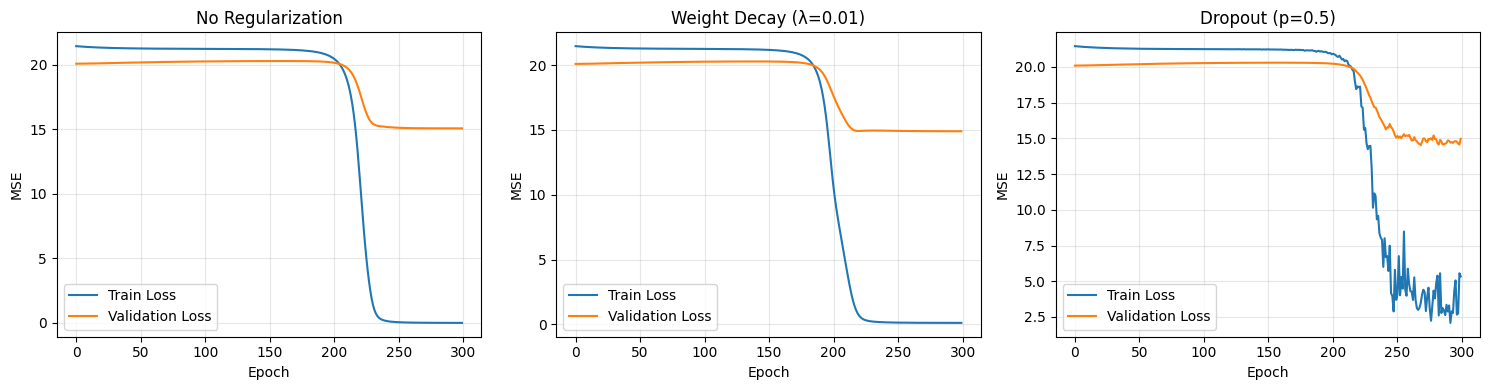

实验总结（最终验证MSE）:
  No Regularization: 15.078626
  Weight Decay (λ=0.01): 14.892612
  Dropout (p=0.5): 14.963057


In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

n_train = 50 
n_test = 200
input_dim = 100  

# 生成数据
X_train = torch.randn(n_train, input_dim)
true_w = torch.randn(input_dim) * 0.5
y_train = X_train @ true_w + torch.randn(n_train) * 0.1

X_test = torch.randn(n_test, input_dim)
y_test = X_test @ true_w + torch.randn(n_test) * 0.1

y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# MLP模型
class MLP:
    def __init__(self, input_dim, hidden_dims, output_dim):
        self.layers = []
        dims = [input_dim] + hidden_dims + [output_dim]
        for i in range(len(dims)-1):
            W = torch.randn(dims[i], dims[i+1]) * 0.01
            b = torch.zeros(dims[i+1])
            W.requires_grad_(True)
            b.requires_grad_(True)
            self.layers.append((W, b))
    
    def forward(self, X, training=True, dropout_rate=0.0):
        h = X
        # 隐藏层
        for i, (W, b) in enumerate(self.layers[:-1]):
            h = h @ W + b
            h = torch.maximum(torch.tensor(0.0), h)  # ReLU
            if training and dropout_rate > 0:
                mask = (torch.rand_like(h) > dropout_rate).float()
                h = h * mask / (1 - dropout_rate)
        # 输出层
        W_out, b_out = self.layers[-1]
        return h @ W_out + b_out
    
    def parameters(self):
        params = []
        for W, b in self.layers:
            params.append(W)
            params.append(b)
        return params
    
    def zero_grad(self):
        for W, b in self.layers:
            if W.grad is not None:
                W.grad.zero_()
            if b.grad is not None:
                b.grad.zero_()


def train_model(model, X_train, y_train, X_val, y_val, 
                lr=0.01, epochs=500, weight_decay=0.0, dropout=0.0):
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        # 前向传播
        pred = model.forward(X_train, training=True, dropout_rate=dropout)
        loss = ((pred - y_train) ** 2).mean()
        
        # L2正则化
        if weight_decay > 0:
            l2_reg = sum((p ** 2).sum() for p in model.parameters()) * weight_decay
            loss = loss + l2_reg
        
        # 反向传播（使用PyTorch自动求导）
        model.zero_grad()
        loss.backward()
        
        # 参数更新
        with torch.no_grad():
            for W, b in model.layers:
                # 权重衰减：w = w - lr * (grad + weight_decay * w)
                W -= lr * (W.grad + weight_decay * W)
                b -= lr * b.grad
        
        # 验证
        with torch.no_grad():
            val_pred = model.forward(X_val, training=False)
            val_loss = ((val_pred - y_val) ** 2).mean()
        
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        
        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}: Train Loss={loss.item():.4f}, Val Loss={val_loss.item():.4f}")
    
    return train_losses, val_losses


# 对比实验
configs = [
    ('No Regularization', 0.0, 0.0),
    ('Weight Decay (λ=0.01)', 0.01, 0.0),
    ('Dropout (p=0.5)', 0.0, 0.5)
]


results = {}
plt.figure(figsize=(15, 4))

for i, (name, wd, dp) in enumerate(configs):
    print(f"=== {name} ===")
    model = MLP(input_dim, [64, 32], 1)
    train_losses, val_losses = train_model(
        model, X_train, y_train, X_test, y_test, 
        lr=0.01, epochs=300, weight_decay=wd, dropout=dp
    )
    results[name] = (train_losses, val_losses)
    
    plt.subplot(1, 3, i+1)
    plt.plot(train_losses, label='Train Loss', linewidth=1.5)
    plt.plot(val_losses, label='Validation Loss', linewidth=1.5)
    plt.title(name, fontsize=12)
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    print(f"最终验证损失: {val_losses[-1]:.4f}\n")

plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=150)
plt.show()

# 打印总结
print("="*50)
print("实验总结（最终验证MSE）:")
for name, (_, val_losses) in results.items():
    print(f"  {name}: {val_losses[-1]:.6f}")

C:\Users\OJY87\AppData\Local\Temp\ipykernel_21728\1356518187.py:36: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


ReLU+大std: 梯度正常


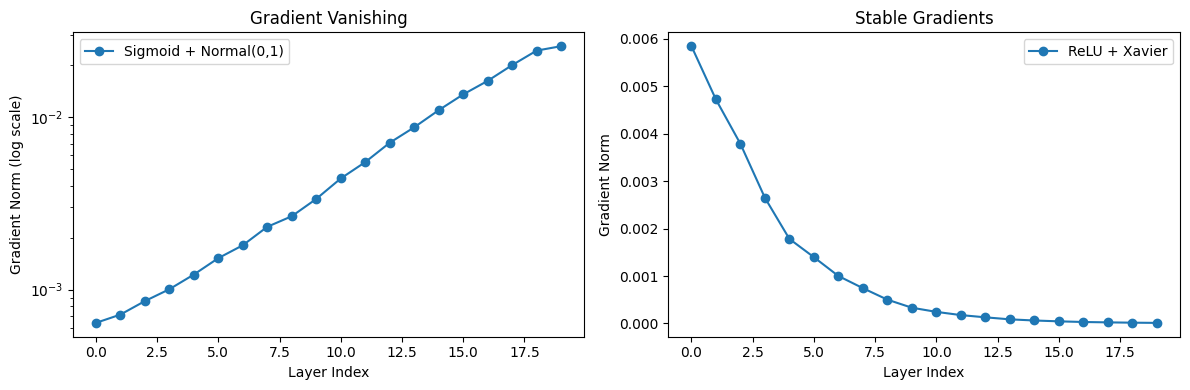

Sigmoid+标准初始化: 首层梯度=6.42e-04, 末层=2.58e-02
Xavier+ReLU: 首层梯度=5.85e-03, 末层=1.16e-05


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 构建20层深层网络
class DeepNet(nn.Module):
    def __init__(self, layers=20, width=256, activation='sigmoid'):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(layers):
            linear = nn.Linear(width, width)
            self.layers.append(linear)
        self.activation = activation
    
    def forward(self, x):
        outputs = []
        for layer in self.layers:
            x = layer(x)
            if self.activation == 'sigmoid':
                x = torch.sigmoid(x)
            elif self.activation == 'relu':
                x = torch.relu(x)
            outputs.append(x)
        return outputs

def compute_gradient_norms(model, x):
    """计算每层梯度的范数"""
    norms = []
    for i, layer in enumerate(model.layers):
        def hook_fn(module, grad_input, grad_output):
            norms.append(grad_output[0].norm().item())
        hook = layer.register_full_backward_hook(hook_fn)
    
    output = model(x)[-1]
    loss = output.mean()
    loss.backward()
    
    for layer in model.layers:
        layer._backward_hooks.clear()
    
    return norms

# Sigmoid + 标准初始化
model1 = DeepNet(activation='sigmoid')
for m in model1.layers:
    nn.init.normal_(m.weight, mean=0, std=1)

x1 = torch.randn(64, 256)
norms1 = compute_gradient_norms(model1, x1)

# 实验2: ReLU + 大初始化
model2 = DeepNet(activation='relu')
for m in model2.layers:
    nn.init.normal_(m.weight, mean=0, std=10)

x2 = torch.randn(64, 256)
try:
    norms2 = compute_gradient_norms(model2, x2)
    print("ReLU+大std: 梯度正常")
except Exception as e:
    print(f"ReLU+大std: 出现NaN - {e}")

# Xavier初始化 + ReLU
model3 = DeepNet(activation='relu')
for m in model3.layers:
    nn.init.xavier_uniform_(m.weight)

x3 = torch.randn(64, 256)
norms3 = compute_gradient_norms(model3, x3)

# 绘制对比
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(norms1, 'o-', label='Sigmoid + Normal(0,1)')
plt.yscale('log')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.legend()
plt.title('Gradient Vanishing')

plt.subplot(1, 2, 2)
plt.plot(norms3, 'o-', label='ReLU + Xavier')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm')
plt.legend()
plt.title('Stable Gradients')
plt.tight_layout()
plt.savefig('numerical_stability.png', dpi=150)
plt.show()

print(f"Sigmoid+标准初始化: 首层梯度={norms1[0]:.2e}, 末层={norms1[-1]:.2e}")
print(f"Xavier+ReLU: 首层梯度={norms3[0]:.2e}, 末层={norms3[-1]:.2e}")

基线模型测试MSE: 0.0120
Epoch 100: Loss=0.6370
Epoch 200: Loss=0.6365
Epoch 300: Loss=0.6365
Epoch 400: Loss=0.6365
Epoch 500: Loss=0.6365

权重统计: min=1.000, max=1.000, mean=1.000
加权模型测试MSE: 0.0117


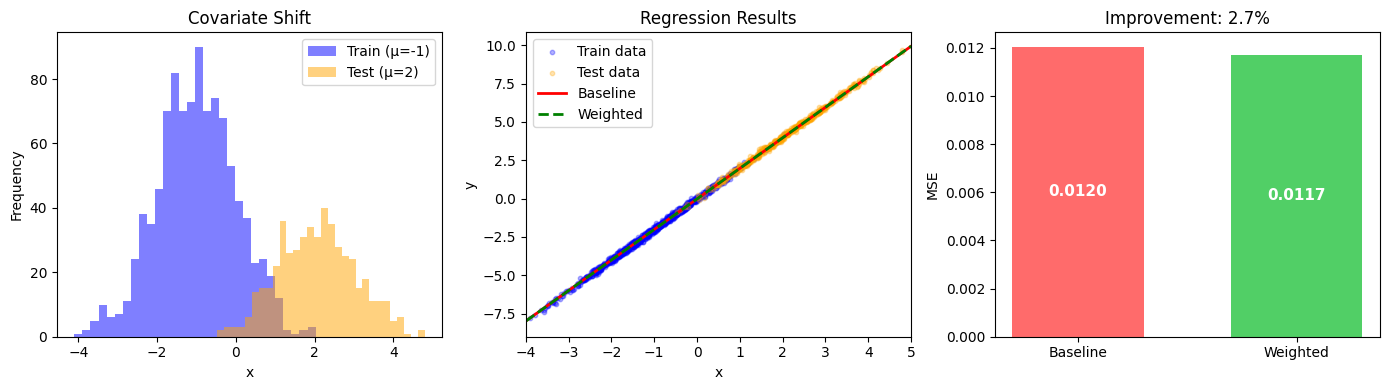

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# 1. 构造数据集
n_train, n_test = 1000, 500
X_train = torch.randn(n_train, 1) - 1
y_train = 2 * X_train + torch.randn(n_train, 1) * 0.1

X_test = torch.randn(n_test, 1) + 2
y_test = 2 * X_test + torch.randn(n_test, 1) * 0.1

# 2. 基线模型
class LinearRegressor:
    def __init__(self):
        self.w = torch.randn(1, 1) * 0.1
        self.b = torch.zeros(1)
        self.w.requires_grad_(True)
        self.b.requires_grad_(True)
    
    def forward(self, X):
        return X @ self.w + self.b
    
    def parameters(self):
        return [self.w, self.b]
    
    def zero_grad(self):
        if self.w.grad is not None:
            self.w.grad.zero_()
        if self.b.grad is not None:
            self.b.grad.zero_()


def train_linear_model(model, X, y, weights=None, lr=0.01, epochs=500):
    losses = []
    for epoch in range(epochs):
        pred = model.forward(X)
        if weights is None:
            loss = ((pred - y) ** 2).mean()
        else:
            loss = ((pred - y) ** 2 * weights).mean()
        
        model.zero_grad()
        loss.backward()
        
        with torch.no_grad():
            for p in model.parameters():
                p -= lr * p.grad
        
        losses.append(loss.item())
    return losses


model_baseline = LinearRegressor()
train_linear_model(model_baseline, X_train, y_train, epochs=500)

with torch.no_grad():
    mse_baseline = ((model_baseline.forward(X_test) - y_test) ** 2).mean().item()
print(f"基线模型测试MSE: {mse_baseline:.4f}")

# 3. 训练偏移校正分类器
X_combined = torch.cat([X_train, X_test], dim=0)
y_combined = torch.cat([torch.zeros(n_train), torch.ones(n_test)])


class LogisticRegressor:
    def __init__(self):
        self.w = torch.randn(1, 1) * 0.1
        self.b = torch.zeros(1)
        self.w.requires_grad_(True)
        self.b.requires_grad_(True)
    
    def forward(self, X):
        logits = X @ self.w + self.b
        return torch.sigmoid(logits)
    
    def parameters(self):
        return [self.w, self.b]
    
    def zero_grad(self):
        if self.w.grad is not None:
            self.w.grad.zero_()
        if self.b.grad is not None:
            self.b.grad.zero_()


classifier = LogisticRegressor()

for epoch in range(500):
    prob = classifier.forward(X_combined)
    loss = - (y_combined * torch.log(prob + 1e-8) + (1 - y_combined) * torch.log(1 - prob + 1e-8)).mean()
    
    classifier.zero_grad()
    loss.backward()
    
    with torch.no_grad():
        classifier.w -= 0.1 * classifier.w.grad
        classifier.b -= 0.1 * classifier.b.grad
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}: Loss={loss.item():.4f}")

# 计算权重
with torch.no_grad():
    p_test_given_x = classifier.forward(X_train).squeeze()
    p_train_given_x = 1 - p_test_given_x
    weights = p_test_given_x / (p_train_given_x + 1e-8)
    weights = weights / weights.mean()

print(f"\n权重统计: min={weights.min():.3f}, max={weights.max():.3f}, mean={weights.mean():.3f}")

# 4. 加权训练
model_weighted = LinearRegressor()
train_linear_model(model_weighted, X_train, y_train, weights=weights.unsqueeze(1), epochs=500)

with torch.no_grad():
    mse_weighted = ((model_weighted.forward(X_test) - y_test) ** 2).mean().item()
print(f"加权模型测试MSE: {mse_weighted:.4f}")

# 可视化结果
plt.figure(figsize=(14, 4))

# 子图1：数据分布
plt.subplot(1, 3, 1)
plt.hist(X_train.numpy(), bins=30, alpha=0.5, label='Train (μ=-1)', color='blue')
plt.hist(X_test.numpy(), bins=30, alpha=0.5, label='Test (μ=2)', color='orange')
plt.xlabel('x')
plt.ylabel('Frequency')
plt.legend()
plt.title('Covariate Shift')

# 子图2：回归结果
plt.subplot(1, 3, 2)
x_vis = torch.linspace(-4, 5, 100).reshape(-1, 1)
with torch.no_grad():
    y_base = model_baseline.forward(x_vis)
    y_weight = model_weighted.forward(x_vis)

plt.scatter(X_train, y_train, alpha=0.3, label='Train data', s=10, color='blue')
plt.scatter(X_test, y_test, alpha=0.3, label='Test data', s=10, color='orange')
plt.plot(x_vis, y_base, 'r-', label='Baseline', linewidth=2)
plt.plot(x_vis, y_weight, 'g--', label='Weighted', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.title('Regression Results')
plt.xlim(-4, 5)

# 子图3：MSE对比
plt.subplot(1, 3, 3)
mse_values = [mse_baseline, mse_weighted]
labels = ['Baseline', 'Weighted']
bars = plt.bar(labels, mse_values, color=['#ff6b6b', '#51cf66'], width=0.6)
plt.ylabel('MSE')
plt.title(f'Improvement: {(1 - mse_weighted/mse_baseline)*100:.1f}%')

for bar, val in zip(bars, mse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
             f'{val:.4f}', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('covariate_shift_correction.png', dpi=150, bbox_inches='tight')
plt.show()